# AP 155 Lab Exercise
---
## Exercise 5: Matrices

_Instructions_:
- **Report figure:** Plot of voltage for each node.
- **Report discussion:**
  - What were the basis linear equations used to set up the matrix in each question of Problem 2?
  - Once you set up the matrices, what function did you use to solve the matrix equation (Could have different answers)? Check the docstring/documentation/other references and summarize the mechanism behind the function
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_:
- _Student No._: 20XX-XXXXX
- _Section_: THR-TX-X

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 |
| Code appropriateness  | XX | 20 |
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->


![w](voltage1.png)

---
## Section 2: Code

### Problem 1: (Newman 6.7) Resistor Ladder

**READ THE INSTRUCTIONS COMPLETELY**

Consider a long chain of resistors wired up like this:

<img src="reschain.png" alt="Alt text" width=95%>

All the resistors have the same resistance $R$.  The power rail at the top is at voltage $V_+=5$V.  The problem is to find the voltages $V_1, \ldots, V_N$ at the internal nodes in the circuit.

1. **Using Ohm's law and the Kirchhoff current law**, which says that the total net current flow out of (or into) any junction in a circuit must be zero, show that the voltages $V_1\ldots V_N$ satisfy the equations

$$3V_1 - V_2 - V_3 = V_+ $$
$$-V_1 + 4V_2 - V_3 - V_4 = V_+ $$
$$\cdots$$
$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0 $$
$$\cdots$$
$$-V_{N-3} - V_{N-2} + 4V_{N-1} - V_N = V_- = 0 $$
$$-V_{N-2} - V_{N-1} + 3V_N = V_- = 0 $$

Note: The assignment of $V_-$ is to make the equations symmetric

2. Express these equations in vector form $A\vec{v} = \vec{w}$ and find the values of the matrix $A$ and the vector $\vec{w}$.

3. Write a program to solve for the values of the $V_i$ when there are $N=6$ internal junctions with unknown voltages. (Hint: All the values of $V_i$ should lie between zero and $5$V.  If they don't, something is wrong.)

4. Now repeat your calculation for the case where there are $N=10\,000$ internal junctions.  This part is not possible using standard tools like the `np.linalg.solve` function.  You need to make use of the fact that the matrix $\vec{A}$ is banded, and uses `banded.py` by Mark Newman which can be obtained from the link: https://public.websites.umich.edu/~mejn/cp/programs.html

5. Plot your voltages in a histogram, make different histograms for varying number of nodes

In [1]:
import numpy as np
import banded as bd
import matplotlib.pyplot as plt


In [2]:
# code here


def createSolve(Vp, Vm, N):
  cMatrix = np.zeros((N, N))
  aVector = np.zeros(N)

  for i in range(N):
    if i == N-1 :
      cMatrix[i,i] = 3
      cMatrix[i,i-1] = -1
      cMatrix[i,i-2] = -1
      aVector[i] = Vm
    elif i == N-2:
      cMatrix[i,i] = 4
      cMatrix[i,i-1] = -1
      cMatrix[i,i-2] = -1
      cMatrix[i,i+1] = -1
      aVector[i] = Vm
    elif i == 0:
      cMatrix[i,i] = 3
      cMatrix[i,i+1] = -1
      cMatrix[i,i+2] = -1
      aVector[i] = Vp
    elif i == 1:
      cMatrix[i,i] = 4
      cMatrix[i,i-1] = -1
      cMatrix[i,i+1] = -1
      cMatrix[i,i+2] = -1
      aVector[i] = Vp
    else:
      cMatrix[i,i] = 4
      cMatrix[i,i-1] = -1
      cMatrix[i,i-2] = -1
      cMatrix[i,i+1] = -1
      cMatrix[i,i+2] = -1
      aVector[i] = 0
  answer = np.linalg.solve(cMatrix, aVector)
  return answer

Ans = createSolve(5, 0, 6)

print(Ans)



# For this algorithm, the upper and lower voltage levels are taken as input, as well as the number of nodes. This can be turned into
# a system of linear equations in a pentadiagonal matrix, where each node has its own linear equation with a known formula. 
# There are only exceptions for the first, second, last, and the second to the last indices. This is then turned into a 
# coefficient matrix with a corresponding answer vector where the constant values of the corresponding linear equations are placed.
# The succeeding matrix equation is run through the built-in python linear algebra solver to find the unknown node voltages.













[3.7254902  3.43137255 2.74509804 2.25490196 1.56862745 1.2745098 ]


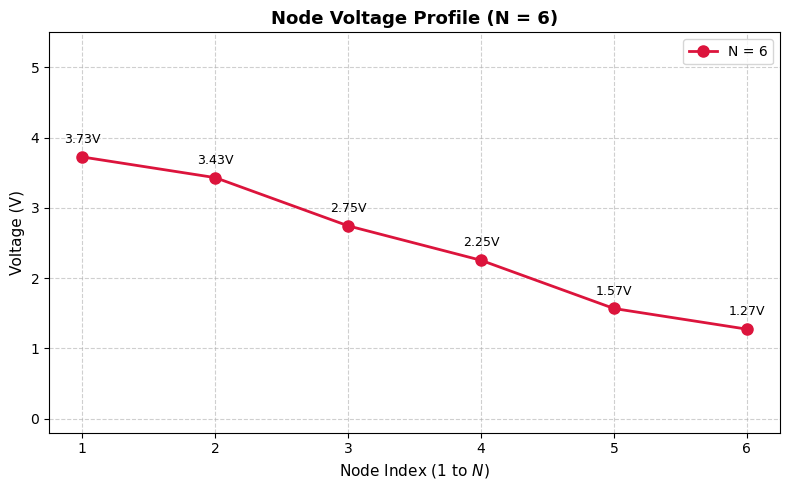

In [27]:
Vp, Vm, N = 5.0, 0.0, 6
Ans = createSolve(Vp, Vm, N)
nodes = np.arange(1, N + 1)

plt.figure(figsize=(8, 5))
plt.plot(
    nodes,
    Ans,
    marker="o",
    color="crimson",
    linewidth=2,
    markersize=8,
    label=f"N = {N}",
)

# Labeling and Formatting
plt.title(
    f"Node Voltage Profile (N = {N})", fontsize=13, fontweight="bold"
)
plt.xlabel("Node Index ($1$ to $N$)", fontsize=11)
plt.ylabel("Voltage (V)", fontsize=11)
plt.xticks(nodes)
plt.ylim(-0.2, Vp + 0.5)
plt.grid(True, linestyle="--", alpha=0.6)

# Value annotations above each point
for node, volt in zip(nodes, Ans):
    plt.annotate(
        f"{volt:.2f}V",
        (node, volt),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
    )

plt.legend()
plt.tight_layout()
plt.savefig("voltage1.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# 4
def bandedSolve(Vp, Vm, N,up,down):

    cMatrix = np.zeros((1 + up + down, N))
    aVector = np.zeros(N)

    # answer vector Boundary Values
    aVector[0] = Vp       
    aVector[1] = Vp       
    aVector[N - 2] = Vm   
    aVector[N - 1] = Vm   
    
    # Matrix Diagonal Values
    cMatrix[2, :] = 4.0
    cMatrix[2, 0] = 3.0       
    cMatrix[2, N - 1] = 3.0

    # First upper and lower rows
    cMatrix[1, 1:] = cMatrix[3, :-1] = cMatrix[0, 2:] = cMatrix[4, :-2] = -1
  
    

    ANN = bd.banded(cMatrix, aVector,2,2)
    return ANN

WAN = bandedSolve(5, 0, 10000,2,2)
print(WAN)


# For the Banded algorithm, the main diagonal of the matrix, a pentadiagonal matrix, is transformed into its own matrix.
# This turns an NXN matrix into a (1 + up + down)xN matrix, in this case a 5XN matrix. The number of upper and lower values 
# above and below the main diagonal is required for this algorithm to run. Thus, each of the diagonal values was turned into its own
# rows, and the initial values of these upper and lower diagonals are zero when they do not correspond to a value in the main diagonal.
# Finally, the newly transformed matrix and the still the same answer vector are run through the Banded imported function to be solved.



[4.99888228e+00 4.99861842e+00 4.99802841e+00 ... 1.97158611e-03
 1.38158071e-03 1.11772227e-03]


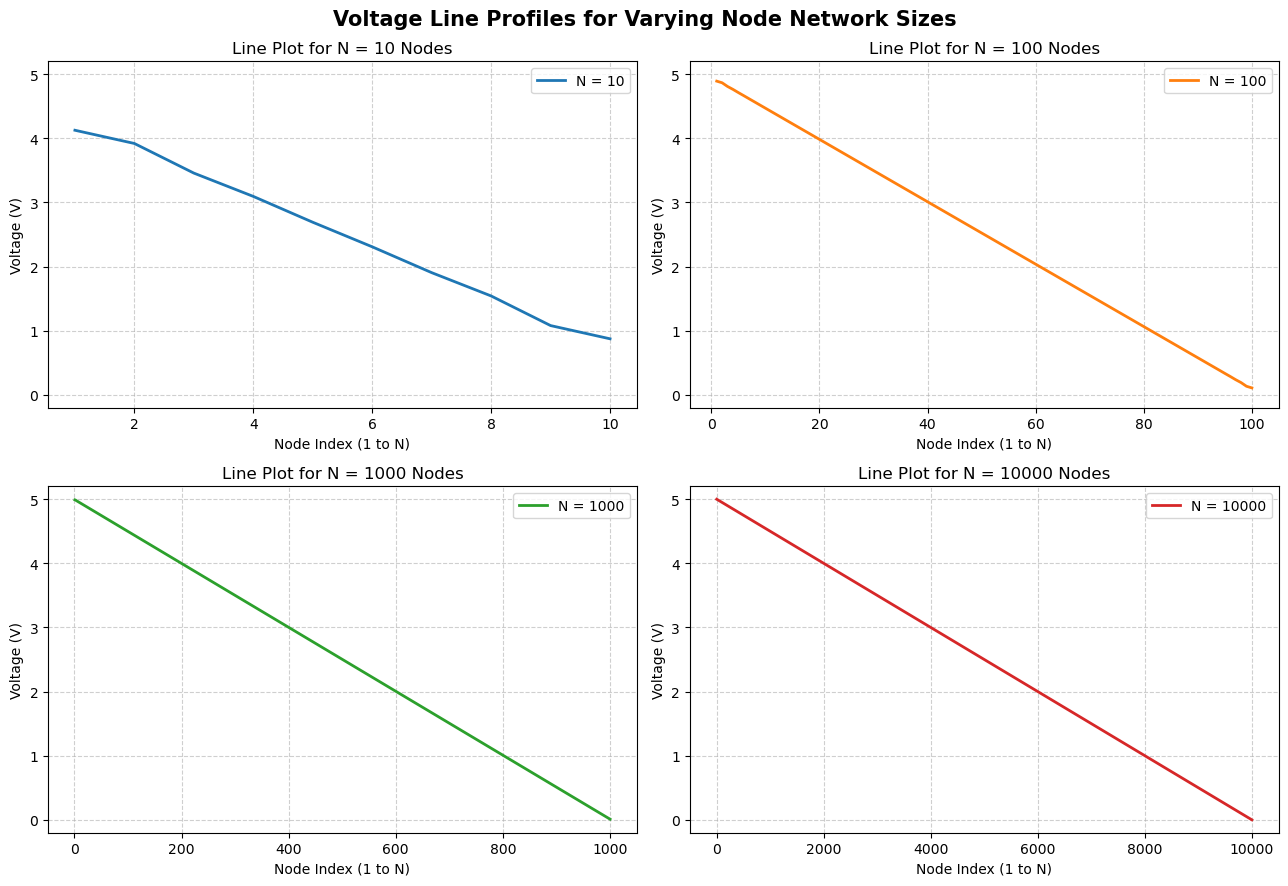

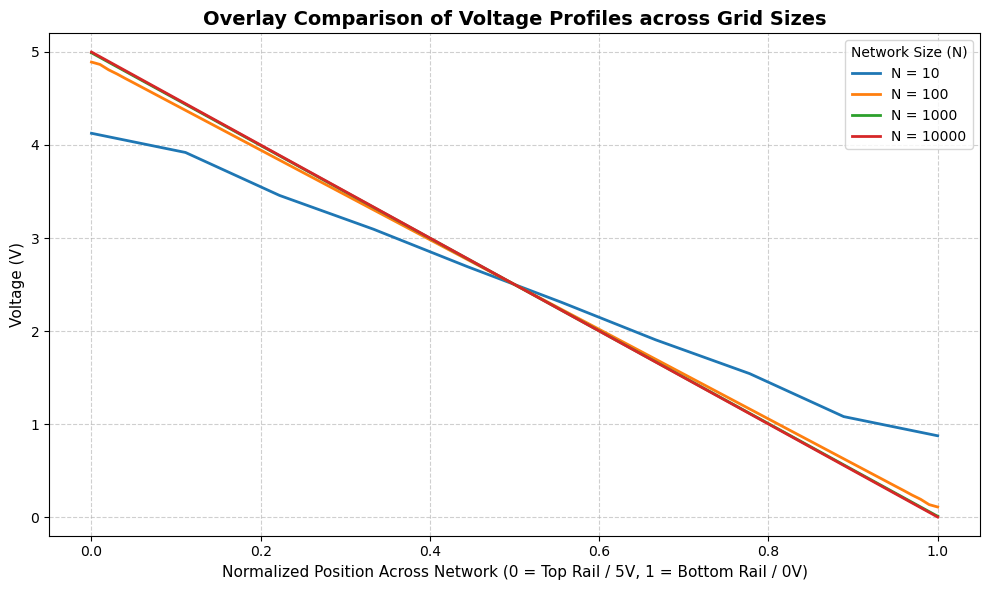

In [25]:
node_sizes = [10, 100, 1000, 10000]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Figure 1: 2x2 Grid of Subplots (Separate plots for each N)
plt.figure(figsize=(13, 9))
plt.suptitle("Voltage Line Profiles for Varying Node Network Sizes", fontsize=15, fontweight='bold')

for idx, N in enumerate(node_sizes, start=1):
    voltages = bandedSolve(5.0, 0.0, N,2,2)
    node_indices = np.arange(1, N + 1)
    
    plt.subplot(2, 2, idx)
    plt.plot(node_indices, voltages, color=colors[idx-1], linewidth=2, label=f'N = {N}')
    plt.title(f"Line Plot for N = {N} Nodes", fontsize=12)
    plt.xlabel("Node Index (1 to N)")
    plt.ylabel("Voltage (V)")
    plt.ylim(-0.2, 5.2)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(loc='upper right')

plt.tight_layout()


# Figure 2: Combined Line Plot (Normalized position for direct comparison)
plt.figure(figsize=(10, 6))

for idx, N in enumerate(node_sizes):
    voltages = bandedSolve(5.0, 0.0, N,2,2)
    # Map node indices onto a normalized scale from 0.0 (Top Rail) to 1.0 (Bottom Rail)
    normalized_position = np.linspace(0, 1, N)
    
    plt.plot(normalized_position, voltages, color=colors[idx], linewidth=2, label=f"N = {N}")

plt.title("Overlay Comparison of Voltage Profiles across Grid Sizes", fontsize=14, fontweight='bold')
plt.xlabel("Normalized Position Across Network (0 = Top Rail / 5V, 1 = Bottom Rail / 0V)", fontsize=11)
plt.ylabel("Voltage (V)", fontsize=11)
plt.ylim(-0.2, 5.2)
plt.legend(title="Network Size (N)")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA).

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)

#### Sample Usage

### Importing functions from a python file